In [1]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
# Analyzes a 1-D FPCA checkpoint. Produce one first with e.g.
#   python fpca.py +fpca_experiment=1d_fpca          (Fourier dictionary)
#   python fpca.py +fpca_experiment=1d_fpca_haar     (Haar wavelet dictionary)
#   python fpca.py +fpca_experiment=1d_fpca_voronoi  (Voronoi dictionary)
# The run directory name is not predictable: `wandb-<run id>` with wandb enabled,
# otherwise a timestamp. List outputs/checkpoints/, pick your run, and use the
# highest step_*.pt (or best.pt) inside it.
CHECKPOINT_DIR  = "../outputs/checkpoints/XXX"
CHECKPOINT_FILE = "step_XXX.pt"
BASIS_VIS_ATOMS = 10
# The raw basis is a blue diagnostic baseline. Training optimizes the
# synthesized dictionary basis, and its orange results are optional below.
SHOW_RAW_REFERENCE = True
SHOW_SYNTHESIZED = True
TRAINED_ATOMS_USE_SYNTHESIS = True

# Sampling, mean, and basis visualizations
B_VIS = 128
SEED0 = 1000
N_MEAN_VIS = 1024
M_MEAN_EST = 2000
N_VIS_ATOM = 1024

# PCA and reconstruction comparison
M_CORPUS = 2048
N_COARSE = 16
N_FINE = 1024
K_PC_SHOW = 8
K_LIST_RECON = [2, 4, 16, 32]
N_RECON_SHOW = 4
SEED_BASE = 5000
SIG_IDX = 2
K_LIST = [1, 2, 4, 8, 12, 16, 24, 32, 48, 64, 96, 128]

# Quantitative raw-versus-learned dictionary comparison
# Run `jupyter execute --inplace --kernel_name=infidictionary notebooks/fpca_1d.ipynb`
# from the repository root to reproduce the table and curve below.
QUANTITATIVE_MSE_HELDOUT = 2048
QUANTITATIVE_MSE_GRID_POINTS = 2048
QUANTITATIVE_MSE_SEED_START = 5000
QUANTITATIVE_MSE_BUDGETS = [2, 4, 8, 16, 32, 64]

# Cayley evolution diagnostics
SNAPSHOT_TIMES = [0.0, 1e-5, 1e-3, 0.01, 0.1, 0.2, 0.5, 0.7, 0.8, 0.9, 1.0]
NUM_STEPS_PER_SNAPSHOT = [2, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100]
ATOM_RANK = 0
N_TEST = 1024
PANEL_YMAX_FACTOR = 2.0
N_ATOMS_GRAM = 8


# 1-D Functional PCA — Discontinuous Sawtooth Toy Dataset

This notebook walks through the 1-D toy FPCA experiment defined by
`OneDimDiscontinuousGenerator`.

The trained FPCA objective uses the configured dictionary's synthesized atoms.
The basis figure additionally shows its raw/base atoms as a diagnostic reference:

1. **Raw initial dictionary** — optional, unmixed atoms before synthesis.
2. **Training dictionary** — the synthesized atoms used by the FPCA objective.
3. **Transported dictionary** — those same synthesized atoms after the trained
   Eulerian isometry pushes them forward.
4. **Coarse-grid PCA** — a discrete baseline evaluated on a small grid.


In [2]:
%load_ext autoreload
%autoreload 2

import sys, os, math, warnings
sys.path.append("..")

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate

from infidictionary.datasets import IrregularDataset, OneDimDiscontinuousGenerator
from infidictionary.dictionaries.base import InfiDictionary
from infidictionary.neural_isometries import NeuralIsometry, IdentityIsometry
from infidictionary.networks import NeuralField
from infidictionary.domain_samplers import SquareSampler

from notebook_helpers import plot_spectral_compactness

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def finite_atom_capacity(dictionary: InfiDictionary) -> int | None:
    """Return a finite dictionary's capacity, or ``None`` for an infinite one."""
    if getattr(dictionary, "is_infinite", False):
        return None
    try:
        return dictionary.get_high_probability_indices(0.0).shape[0]
    except ValueError:
        # Infinite dictionaries, such as Haar, cannot enumerate every
        # positive-PMF atom at a zero threshold.
        return None


def cap_atom_budgets(budgets, capacity: int | None, *, label: str) -> list[int]:
    """Clamp budgets only when the dictionary has finite support."""
    if capacity is None:
        return list(dict.fromkeys(int(budget) for budget in budgets))
    if capacity < 1:
        raise ValueError("The dictionary exposes no atoms with positive probability.")
    capped = list(dict.fromkeys(min(int(budget), capacity) for budget in budgets))
    if capped != list(budgets):
        warnings.warn(
            f"{label}: clamped requested atom budgets {list(budgets)} to {capped}; "
            f"the dictionary exposes only {capacity} atoms.",
            stacklevel=2,
        )
    return capped


def top_probability_indices(dictionary: InfiDictionary, count: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Return top-PMF atoms without enumerating an infinite dictionary."""
    if count < 1:
        raise ValueError("count must be positive")
    capacity = finite_atom_capacity(dictionary)
    if capacity is not None and count > capacity:
        warnings.warn(
            f"Requested {count} atoms, but the dictionary exposes {capacity}; "
            f"using all available atoms.",
            stacklevel=2,
        )
        count = capacity
    threshold = 1.0
    for _ in range(128):
        candidates = dictionary.get_high_probability_indices(threshold)
        if candidates.shape[0] >= count:
            pmfs = dictionary.get_index_pmfs(candidates)
            order = torch.argsort(pmfs, descending=True, stable=True)[:count]
            return candidates[order].to(device), pmfs[order].to(device)
        threshold *= 0.5
    raise RuntimeError(
        f"Could not find {count} atoms after 128 positive-PMF thresholds; "
        "check the dictionary PMF implementation."
    )

Device: cuda


## 1. Load a trained checkpoint

Set `CHECKPOINT_DIR` and `CHECKPOINT_FILE` below to a run produced by

```bash
python fpca.py +fpca_experiment=1d_fpca \
    wandb=enabled wandb.run_name=1d_p05
```

If you haven't trained yet, run that first and then re-run this cell.

In [3]:

with open(f"{CHECKPOINT_DIR}/config.yaml") as f:
    conf = OmegaConf.create(yaml.safe_load(f))

neural_isometry:    NeuralIsometry  = instantiate(conf.neural_isometry).to(device)
mean_function:      NeuralField     = instantiate(conf.mean_function).to(device)
initial_dictionary: InfiDictionary  = instantiate(conf.initial_dictionary)
function_generator: IrregularDataset = instantiate(conf.function_generator)

ckpt = torch.load(f"{CHECKPOINT_DIR}/{CHECKPOINT_FILE}", map_location=device, weights_only=False)
neural_isometry.load_state_dict(ckpt["models"]["neural_isometry"])
mean_function.load_state_dict(ckpt["models"]["mean_function"])
initial_dictionary.load_state_dict(ckpt["models"]["initial_dictionary"])

model_state_kwargs = OmegaConf.to_container(
    conf.get("model_state_kwargs", {"num_steps": 20}), resolve=True,
)
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval(); mean_function.eval()

pullback_kwargs = OmegaConf.to_container(
    conf.get("pullback_pushforward_kwargs", {}), resolve=True,
)

print(f"Loaded   : {CHECKPOINT_DIR}/{CHECKPOINT_FILE}  (epoch {ckpt['epoch']})")
print(f"Metric   : {ckpt['metric']:.4f}  |  best: {ckpt['best_metric']:.4f}")
dictionary_name = type(initial_dictionary).__name__
raw_basis_label = f"Raw {dictionary_name}"
training_basis_label = (
    f"Synthesized {dictionary_name}"
    if TRAINED_ATOMS_USE_SYNTHESIS
    else raw_basis_label
)
transported_basis_label = "Learned Dictionary"

print(f"Generator: {type(function_generator).__name__}  |  rank: {conf.neural_isometry.rank}")
print(f"Training basis: {training_basis_label}")


Loaded   : ../outputs/checkpoints/wandb-XXX/step_XXX.pt  (epoch 3999)
Metric   : 0.3526  |  best: 0.4147
Generator: OneDimDiscontinuousGenerator  |  rank: 32
Training basis: Synthesized FourierDictionary


## 2. Dataset preview

Overlay 128 sample functions from the loaded `function_generator`. Each unique $k$ value gets one colour; the legend entry shows how many times that $k$ appeared in this draw (multiplicity), which reflects the geometric prior $k \sim \text{Geom}(p)$.

In [4]:
from collections import Counter

x_dense = torch.linspace(0.0, 1.0, 1024).unsqueeze(-1)

# Draw k for every sample upfront so we know the multiplicity.
ks = [function_generator._sample_k(SEED0 + j) for j in range(B_VIS)]
k_counts   = Counter(ks)
k_sorted   = sorted(k_counts.keys())

# Assign a consistent colour to each unique k value.
palette  = plt.cm.tab20.colors
k_color  = {k: palette[i % len(palette)] for i, k in enumerate(k_sorted)}

fig, ax = plt.subplots(figsize=(9, 3.8))
seen = set()
for j in range(B_VIS):
    k = ks[j]
    f = function_generator._eval(x_dense, seed=SEED0 + j).squeeze(-1).numpy()
    cnt   = k_counts[k]
    label = rf"k={k}  ($\times${cnt})" if k not in seen else "_nolegend_"
    seen.add(k)
    ax.plot(x_dense.squeeze(-1).numpy(), f,
            alpha=0.35, lw=0.9, color=k_color[k], label=label)

ax.axvline(0.5, color="k", ls="--", lw=0.7, alpha=0.4)
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.set_title(f"{B_VIS} samples from function_generator  (colour = k, legend shows multiplicity)")
ax.legend(fontsize=7, ncol=8, loc="lower center", framealpha=0.85)
ax.grid(alpha=0.3)
plt.close()  # Gram matrices are included in the combined evolution figure above.

## 3. Learned mean function

The training loop fits a `NeuralField` that approximates the empirical mean
$\mu(x) = \mathbb{E}[f(x)]$.  We visualise it here alongside the Monte-Carlo
estimate of the true mean built from the corpus (dashed line).  The two should
agree well once training has converged.

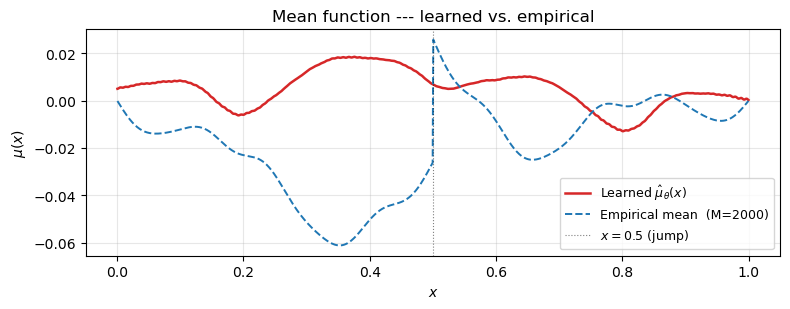

Max pointwise error |learned - empirical|: 0.0793


In [5]:

x_vis = SquareSampler(domain_dim=1, stratified=True, add_noise=False).sample(N_MEAN_VIS)  # (N, 1)
x_vis_dev = x_vis.to(device)

# Learned mean: forward pass on the fine grid.
with torch.no_grad():
    mu_pred = mean_function(x_vis_dev).cpu().squeeze(-1)   # (N,)

# Empirical mean: average M_MEAN_EST draws from the generator.
# Use the same generator that was instantiated from the config.
emp_vals = torch.stack(
    [function_generator._eval(x_vis, seed=s).squeeze(-1) for s in range(M_MEAN_EST)],
    dim=0,
).mean(dim=0)  # (N,)

x_np      = x_vis.squeeze(-1).numpy()
order_x   = np.argsort(x_np)
x_sorted  = x_np[order_x]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(x_sorted, mu_pred.numpy()[order_x],   color="C3",  lw=1.8,
        label=r"Learned $\hat\mu_\theta(x)$")
ax.plot(x_sorted, emp_vals.numpy()[order_x],  color="C0",  lw=1.4, ls="--",
        label=f"Empirical mean  (M={M_MEAN_EST})")
ax.axvline(0.5, color="k", ls=":", lw=0.8, alpha=0.5, label="$x=0.5$ (jump)")
ax.set_xlabel("$x$"); ax.set_ylabel(r"$\mu(x)$")
ax.set_title("Mean function --- learned vs. empirical")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Max pointwise error |learned - empirical|: "
      f"{np.abs((mu_pred.numpy() - emp_vals.numpy()).max()):.4f}")


## 4. Raw reference and learned principal functions

The blue row is the raw/base dictionary reference. When `SHOW_SYNTHESIZED` is
true, the orange row shows the synthesized atoms used by the FPCA objective.
The final red row is the learned dictionary: those training atoms after the
trained isometry pushes them forward.


/tmp/ipykernel_3800268/1614587119.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.87])


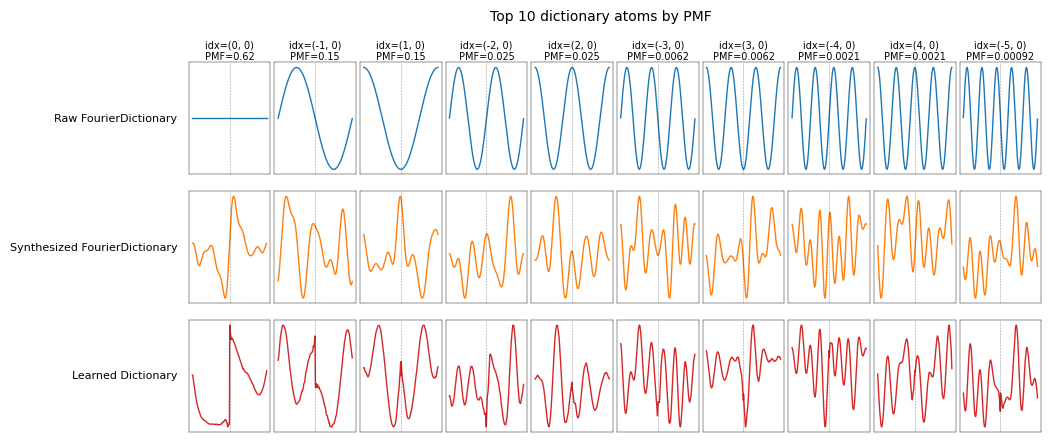

In [6]:
# One dictionary-neutral atom budget, configured in the parameter cell.
coords_fine = SquareSampler(domain_dim=1, stratified=True, add_noise=False).sample(N_VIS_ATOM).to(device)
lad_fine = torch.zeros(coords_fine.shape[0], device=device)
indices_wn, nu_wn = top_probability_indices(initial_dictionary, BASIS_VIS_ATOMS)

neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    atoms_training = initial_dictionary.get_atoms(
        coords_fine, indices_wn, synthesis=TRAINED_ATOMS_USE_SYNTHESIS,
    )
    _, _, atoms_transported = neural_isometry.pushforward(
        coords_fine, lad_fine, atoms_training, **pullback_kwargs,
    )
    atoms_raw = initial_dictionary.get_atoms(coords_fine, indices_wn, synthesis=False)

rows = []
if SHOW_RAW_REFERENCE:
    rows.append((atoms_raw, "C0", raw_basis_label))
if SHOW_SYNTHESIZED:
    rows.append((atoms_training, "C1", training_basis_label))
rows.append((atoms_transported, "C3", transported_basis_label))
A = atoms_training.shape[0]
x_np = coords_fine.squeeze(-1).cpu().numpy()
order_x = np.argsort(x_np)
x_sorted = x_np[order_x]

fig, axes = plt.subplots(
    len(rows), A, figsize=(A * 1.0 + 1.0, 1.45 * len(rows) + 0.45),
    sharex=True, sharey=False, squeeze=False,
    gridspec_kw={"wspace": 0.05, "hspace": 0.15},
)
for j in range(A):
    index_text = ", ".join(str(value) for value in indices_wn[j].tolist())
    for row, (atoms, color, label) in enumerate(rows):
        values = atoms[j].squeeze(-1).cpu().numpy()[order_x]
        axes[row, j].plot(x_sorted, values, color=color, lw=1.0)
        axes[row, j].axvline(0.5, color="k", ls="--", lw=0.4, alpha=0.4)
        axes[row, j].set_xticks([])
        axes[row, j].set_yticks([])
        for spine in axes[row, j].spines.values():
            spine.set_linewidth(0.3)
    axes[0, j].set_title(f"idx=({index_text})\nPMF={nu_wn[j].item():.2g}", fontsize=7, pad=2)
for row, (_, _, label) in enumerate(rows):
    axes[row, 0].set_ylabel(label, fontsize=8, rotation=0, ha="right", va="center", labelpad=8)
fig.suptitle(f"Top {A} dictionary atoms by PMF", fontsize=10, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.87])
plt.show()


## 5. Coarse-grid PCA baseline

Build a large training corpus and compute classical PCA on it at a **coarse
grid** of $N_{\rm coarse}$ points. Each principal component is just a vector in
$\mathbb{R}^{N_{\rm coarse}}$ — to use it on a finer test grid we have to
interpolate, and the discretization error shows up directly in the captured
energy.

corpus_fine: (2048, 1024, 1)
Top-1 PC explains 62.67% of coarse variance
Top-5 PCs explain 98.13%   of coarse variance


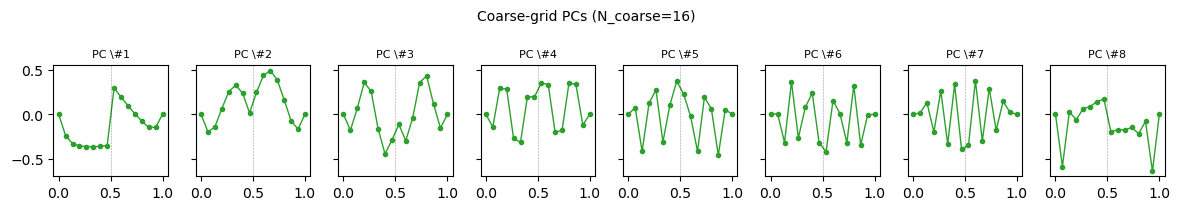

In [7]:
# Reference fine-grid corpus (the "ground truth" L2 evaluation).
x_fine = torch.linspace(0.0, 1.0, N_FINE).unsqueeze(-1)
corpus_fine = torch.stack(
    [function_generator._eval(x_fine, seed=s) for s in range(M_CORPUS)], dim=0,
)  # (M, N_FINE, 1)
print("corpus_fine:", tuple(corpus_fine.shape))

# Coarse-grid corpus + PCA.
x_coarse = torch.linspace(0.0, 1.0, N_COARSE).unsqueeze(-1)
corpus_coarse = torch.stack(
    [function_generator._eval(x_coarse, seed=s) for s in range(M_CORPUS)], dim=0,
).squeeze(-1)  # (M, N_COARSE)

mean_coarse = corpus_coarse.mean(dim=0)
X_centered  = corpus_coarse - mean_coarse
_, S, Vh    = torch.linalg.svd(X_centered, full_matrices=False)
ev          = (S ** 2) / (S ** 2).sum()
print(f"Top-1 PC explains {ev[0].item()*100:.2f}% of coarse variance")
print(f"Top-5 PCs explain {ev[:5].sum().item()*100:.2f}%   of coarse variance")

# Plot top coarse PCs (each is a R^{N_COARSE} vector - show as step-line).
fig, axes = plt.subplots(1, K_PC_SHOW, figsize=(1.5 * K_PC_SHOW, 2.1),
                         sharey=True, squeeze=False)
xc_np = x_coarse.squeeze(-1).numpy()
for k, ax in enumerate(axes[0]):
    ax.plot(xc_np, Vh[k].cpu().numpy(), "o-", ms=3, lw=1.0, color="C2")
    ax.axvline(0.5, color="k", ls="--", lw=0.4, alpha=0.4)
    ax.set_title(rf"PC \#{k+1}", fontsize=8); ax.set_xticks([0, 0.5, 1])
plt.suptitle(f"Coarse-grid PCs (N_coarse={N_COARSE})", fontsize=10)
plt.tight_layout(); plt.show()


## 6. Reconstructions

The blue row reconstructs with raw/base initial-dictionary atoms. The red
**Learned Dictionary** row uses the transported synthesized atoms that
correspond to the trained FPCA basis. Set `SHOW_SYNTHESIZED = True` to include
the orange synthesized-basis row as the direct pre-transport comparison.
Coarse-grid PCA remains a separate finite-resolution baseline.


selected seeds = [5000, 5001, 5003, 5006]  |  k values = [2, 1, 3, 4]


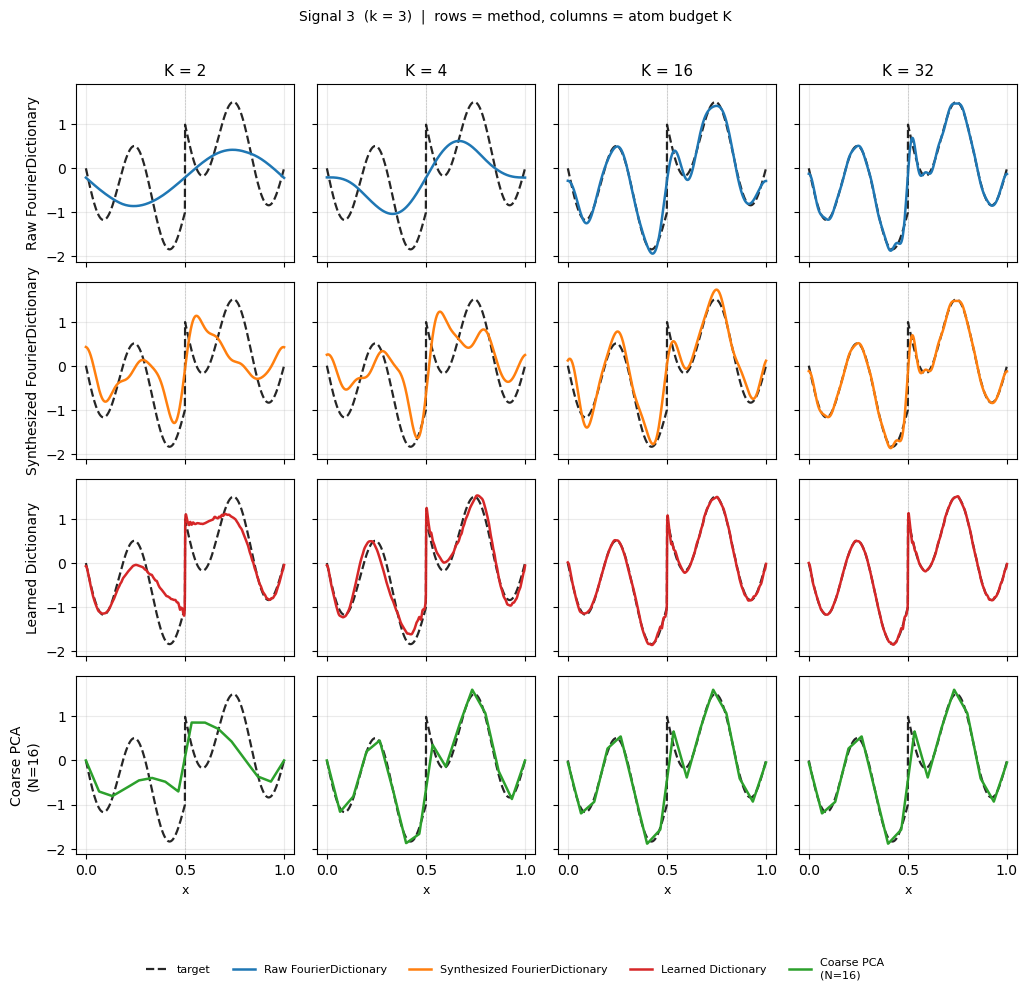

In [8]:
from matplotlib.lines import Line2D

chosen_seeds, chosen_ks = [], []
seed = SEED_BASE
while len(chosen_seeds) < N_RECON_SHOW:
    k = function_generator._sample_k(seed)
    if k not in chosen_ks:
        chosen_seeds.append(seed)
        chosen_ks.append(k)
    seed += 1
print(f'selected seeds = {chosen_seeds}  |  k values = {chosen_ks}')

N_RECON = x_fine.shape[0]
x_recon = x_fine.to(device)
lad_recon = torch.zeros(N_RECON, device=device)
targets = torch.stack([
    function_generator._eval(x_fine, seed=s).squeeze(-1) for s in chosen_seeds
], dim=0).to(device)

xc_np = x_coarse.squeeze(-1).numpy()
xf_np = x_fine.squeeze(-1).numpy()
with torch.no_grad():
    mu_tr = mean_function(x_recon).squeeze(-1)
mu_pca = torch.from_numpy(np.interp(xf_np, xc_np, mean_coarse.numpy())).float().to(device)

K_LIST_RECON = cap_atom_budgets(
    K_LIST_RECON, finite_atom_capacity(initial_dictionary), label="Reconstruction",
)
indices_top, _ = top_probability_indices(initial_dictionary, max(K_LIST_RECON))
neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    atoms_raw_max = initial_dictionary.get_atoms(x_recon, indices_top, synthesis=False)
    atoms_training_max = initial_dictionary.get_atoms(
        x_recon, indices_top, synthesis=TRAINED_ATOMS_USE_SYNTHESIS,
    )
    _, _, atoms_transported_max = neural_isometry.pushforward(
        x_recon, lad_recon, atoms_training_max, **pullback_kwargs,
    )
atoms_raw_max = atoms_raw_max.squeeze(-1)
atoms_training_max = atoms_training_max.squeeze(-1)
atoms_transported_max = atoms_transported_max.squeeze(-1)

K_PCA_MAX = Vh.shape[0]
pcs_raw = np.stack([np.interp(xf_np, xc_np, Vh[k].cpu().numpy()) for k in range(K_PCA_MAX)])
atoms_PCA_max = torch.from_numpy(pcs_raw).double().to(device)
atoms_PCA_max = atoms_PCA_max / ((atoms_PCA_max ** 2).sum(dim=1, keepdim=True) / N_RECON).sqrt().clamp(min=1e-12)

def reconstruct(atoms, mean, target):
    centered = target - mean
    gram = atoms @ atoms.T / N_RECON
    coefficients = atoms @ centered / N_RECON
    return mean + coefficients @ torch.linalg.pinv(gram) @ atoms

methods = {
    'Raw': (atoms_raw_max, mu_tr),
    'Transported': (atoms_transported_max, mu_tr),
    'Coarse PCA': (atoms_PCA_max, mu_pca),
}
if SHOW_SYNTHESIZED:
    methods['Synthesized'] = (atoms_training_max, mu_tr)

with torch.no_grad():
    recons = {method: {} for method in methods}
    for K in K_LIST_RECON:
        for method, (atoms, mean) in methods.items():
            active = atoms[:min(K, atoms.shape[0])]
            for c, target in enumerate(targets):
                recons[method][(K, c)] = reconstruct(active, mean, target).cpu().numpy()

ROWS = [('Raw', 'C0', raw_basis_label)]
if SHOW_SYNTHESIZED:
    ROWS.append(('Synthesized', 'C1', training_basis_label))
ROWS.extend([
    ('Transported', 'C3', transported_basis_label),
    ('Coarse PCA', 'C2', f'Coarse PCA\n(N={N_COARSE})'),
])
fig, axes = plt.subplots(len(ROWS), len(K_LIST_RECON), figsize=(2.6 * len(K_LIST_RECON), 2.45 * len(ROWS)), sharex=True, sharey='all', squeeze=False)
target_np = targets[SIG_IDX].cpu().numpy()
for row, (method, color, row_label) in enumerate(ROWS):
    for col, K in enumerate(K_LIST_RECON):
        ax = axes[row, col]
        ax.plot(xf_np, target_np, color='k', lw=1.6, ls='--', alpha=0.85)
        ax.plot(xf_np, recons[method][(K, SIG_IDX)], color=color, lw=1.8)
        ax.axvline(0.5, color='k', ls=':', lw=0.4, alpha=0.4)
        ax.grid(alpha=0.25)
        ax.set_xticks([0, 0.5, 1])
        if row == 0:
            ax.set_title(f'K = {min(K, atoms_raw_max.shape[0])}', fontsize=11)
        if col == 0:
            ax.set_ylabel(row_label, fontsize=10)
        if row == len(ROWS) - 1:
            ax.set_xlabel('x', fontsize=9)

legend_handles = [Line2D([0], [0], color='k', lw=1.6, ls='--', alpha=0.85, label='target')]
for _, color, label in ROWS:
    legend_handles.append(Line2D([0], [0], color=color, lw=1.8, label=label))
fig.legend(handles=legend_handles, loc='lower center', ncol=len(legend_handles), fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f'Signal {SIG_IDX + 1}  (k = {chosen_ks[SIG_IDX]})  |  rows = method, columns = atom budget K', fontsize=10)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()


## 7. Captured and residual energy

The blue curve measures raw/base initial-dictionary atoms. The red **Learned
Dictionary** curve uses the transported synthesized atoms that define the
trained FPCA basis. Set
`SHOW_SYNTHESIZED = True` to include the orange synthesized-basis curve before
transport; this makes the effect of the isometry directly visible.


Total centred L2 energy: 1706.0614
Projection atoms available: 128


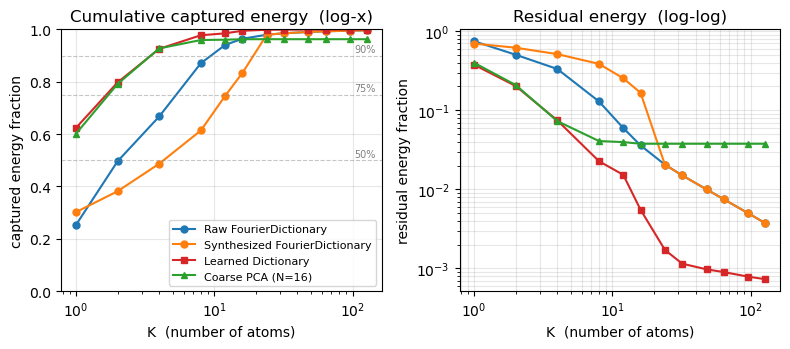

In [9]:
coords_proj = x_fine.to(device)
lad_proj = torch.zeros(coords_proj.shape[0], device=device)
N = coords_proj.shape[0]

with torch.no_grad():
    mu_fine = mean_function(coords_proj).cpu()
corpus_centered = (corpus_fine - mu_fine.unsqueeze(0)).to(device)
total_energy = (corpus_centered ** 2).sum().item() / N
print(f"Total centred L2 energy: {total_energy:.4f}")

K_LIST = cap_atom_budgets(
    K_LIST, finite_atom_capacity(initial_dictionary), label="Energy curve",
)
indices_proj, _ = top_probability_indices(initial_dictionary, max(K_LIST))
print(f"Projection atoms available: {indices_proj.shape[0]}")

def captured_curve(atoms, functions, budgets):
    values = []
    for budget in budgets:
        active = atoms[:min(budget, atoms.shape[0])]
        gram = torch.einsum("anC,bnC->ab", active, active) / N
        coefficients = torch.einsum("anC,mnC->ma", active, functions) / N
        weights = coefficients @ torch.linalg.pinv(gram)
        values.append((weights * coefficients).sum().item())
    return np.asarray(values)

neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    atoms_raw = initial_dictionary.get_atoms(coords_proj, indices_proj, synthesis=False)
    atoms_training = initial_dictionary.get_atoms(
        coords_proj, indices_proj, synthesis=TRAINED_ATOMS_USE_SYNTHESIS,
    )
    _, _, atoms_transported = neural_isometry.pushforward(
        coords_proj, lad_proj, atoms_training, **pullback_kwargs,
    )
    captured_raw = captured_curve(atoms_raw, corpus_centered, K_LIST)
    captured_training = captured_curve(atoms_training, corpus_centered, K_LIST)
    captured_transported = captured_curve(atoms_transported, corpus_centered, K_LIST)

xc_np = x_coarse.squeeze(-1).numpy()
xf_np = x_fine.squeeze(-1).numpy()
n_pcs = Vh.shape[0]
pcs_fine = np.stack([np.interp(xf_np, xc_np, Vh[k].cpu().numpy()) for k in range(n_pcs)], axis=0)
pcs_fine_t = torch.from_numpy(pcs_fine).double().to(device)
pcs_norm_l2 = ((pcs_fine_t ** 2).sum(dim=1) / N).sqrt().clamp(min=1e-12)
atoms_PCA = (pcs_fine_t / pcs_norm_l2.unsqueeze(-1)).unsqueeze(-1)
mu_coarse_fine = torch.from_numpy(np.interp(xf_np, xc_np, mean_coarse.numpy())).double()
corpus_for_pca = (corpus_fine.squeeze(-1) - mu_coarse_fine.unsqueeze(0)).unsqueeze(-1).to(device)
captured_pca = captured_curve(atoms_PCA, corpus_for_pca, K_LIST)

curves = [dict(label=raw_basis_label, xs=K_LIST, mean=captured_raw / total_energy, color="C0", marker='o')]
if SHOW_SYNTHESIZED:
    curves.append(dict(label=training_basis_label, xs=K_LIST, mean=captured_training / total_energy, color="C1", marker='o'))
curves.extend([
    dict(label=transported_basis_label, xs=K_LIST, mean=captured_transported / total_energy, color="C3", marker='s'),
    dict(label=f"Coarse PCA (N={N_COARSE})", xs=K_LIST, mean=captured_pca / total_energy, color="C2", marker='^'),
])
fig, _ = plot_spectral_compactness(curves, figsize=(8, 3.6), xlabel="K  (number of atoms)")
plt.tight_layout()
plt.show()


### Discussion

* The training-dictionary curve measures the basis that was actually optimized
  by FPCA, including its learned synthesis when enabled.
* The transported curve measures whether the learned isometry concentrates the
  corpus energy into prefixes of that same trained basis.
* The raw reference in §4 is useful for interpreting what synthesis changed,
  but it is not used for the FPCA reconstruction or energy metrics.
* Coarse PCA is limited by the resolution of the grid on which its components
  were learned; interpolation to the fine grid exposes that discretization gap.


## 8. Cayley evolution of a trained-basis atom

We evolve one high-PMF atom from the synthesized training dictionary with the
structure-preserving Cayley map. The figure pairs each snapshot with the Gram
matrix of the same leading training-basis atoms at that time.


In [10]:
# Cayley evolution snapshots; controls are in the parameter cell.
assert len(NUM_STEPS_PER_SNAPSHOT) == len(SNAPSHOT_TIMES)

x_test = SquareSampler(domain_dim=1, stratified=True, add_noise=False).sample(N_TEST).to(device)
lad_test = torch.zeros(N_TEST, device=device)

with torch.no_grad():
    chosen_index, _ = top_probability_indices(initial_dictionary, ATOM_RANK + 1)
    f0 = initial_dictionary.get_atoms(
        x_test, chosen_index[-1:], synthesis=TRAINED_ATOMS_USE_SYNTHESIS,
    )

frames = [f0[0].clone()]
for t_target, n_steps in zip(SNAPSHOT_TIMES[1:], NUM_STEPS_PER_SNAPSHOT[1:]):
    neural_isometry.shuffle_model_state(num_steps=n_steps)
    with torch.no_grad():
        _, _, evolved = neural_isometry.pushforward(x_test, lad_test, f0, 0.0, t_target)
    frames.append(evolved[0].clone())


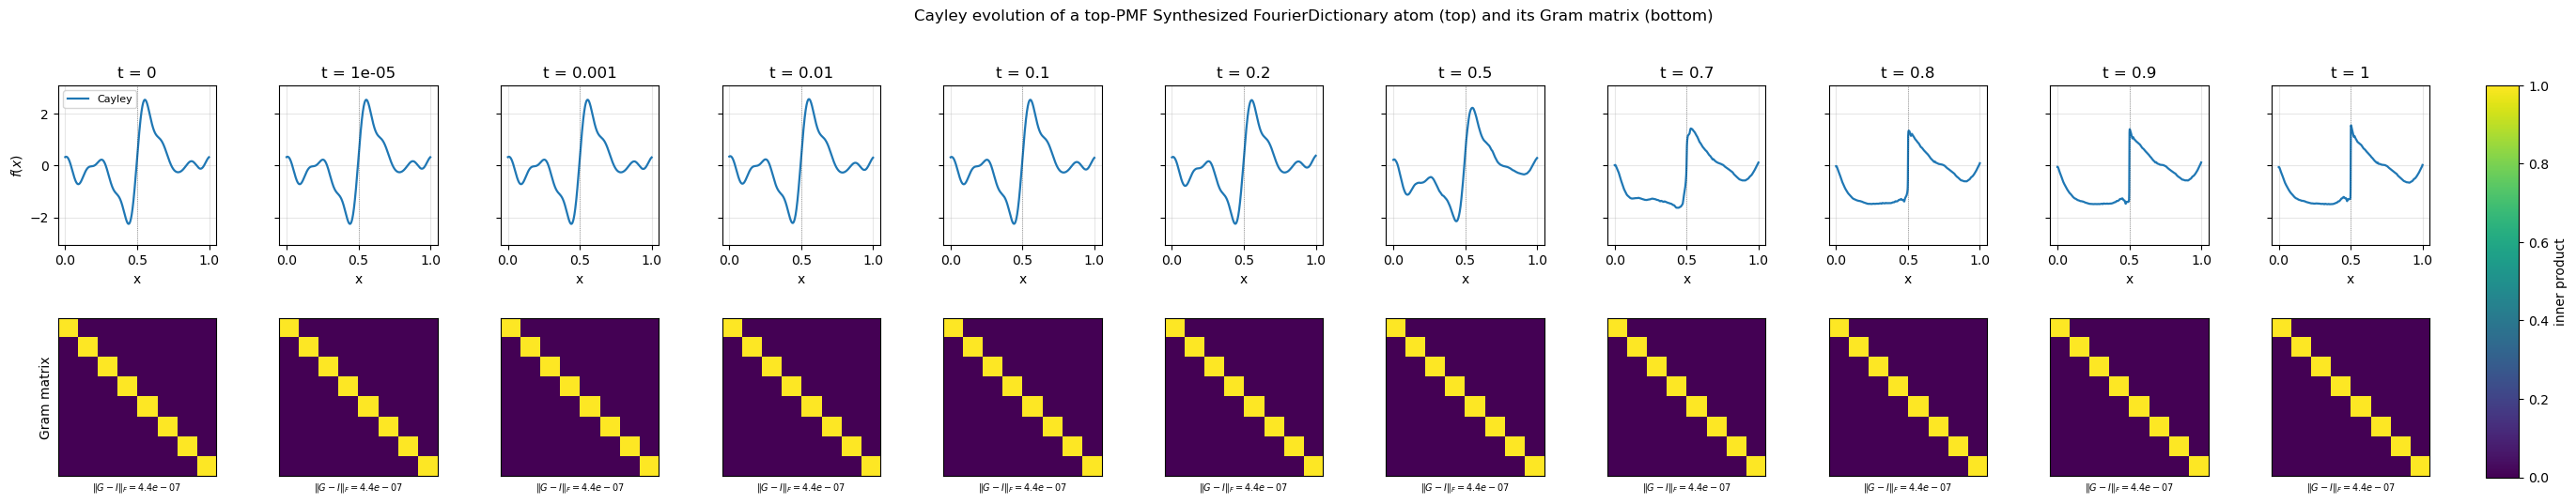

In [11]:
# Signal evolution (top) and Gram matrices (bottom) at matching times.

x_np = x_test.squeeze(-1).cpu().numpy()
order_x = np.argsort(x_np)
x_sorted = x_np[order_x]

fig, axes = plt.subplots(
    2, len(SNAPSHOT_TIMES), figsize=(2.7 * len(SNAPSHOT_TIMES), 5.8),
    sharey='row', squeeze=False,
)

for col, (t_target, frame) in enumerate(zip(SNAPSHOT_TIMES, frames)):
    ax = axes[0, col]
    values = frame.squeeze(-1).cpu().numpy()[order_x]
    ymax = PANEL_YMAX_FACTOR * (float(np.abs(values).max()) + 1e-12)
    ax.plot(x_sorted, values, color='C0', lw=1.6, label='Cayley' if col == 0 else None)
    ax.axvline(0.5, color='k', ls=':', lw=0.6, alpha=0.4)
    ax.set_title(f't = {t_target:g}')
    ax.set_xlabel('x')
    ax.set_ylim(-ymax, ymax)
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel(r'$f(x)$')
        ax.legend(fontsize=8)

capacity_gram = finite_atom_capacity(initial_dictionary)
n_atoms_gram = N_ATOMS_GRAM if capacity_gram is None else min(N_ATOMS_GRAM, capacity_gram)
if n_atoms_gram != N_ATOMS_GRAM:
    warnings.warn(
        f"Gram matrix: using {n_atoms_gram} atoms because the dictionary exposes only "
        f"{n_atoms_gram} atoms.",
        stacklevel=1,
    )
idx_gram, _ = top_probability_indices(initial_dictionary, n_atoms_gram)
with torch.no_grad():
    atoms_gram = initial_dictionary.get_atoms(
        x_test, idx_gram, synthesis=TRAINED_ATOMS_USE_SYNTHESIS,
    )

for col, (t_target, n_steps) in enumerate(zip(SNAPSHOT_TIMES, NUM_STEPS_PER_SNAPSHOT)):
    ax = axes[1, col]
    if t_target == 0.0:
        evolved_atoms = atoms_gram
    else:
        neural_isometry.shuffle_model_state(num_steps=n_steps)
        with torch.no_grad():
            _, _, evolved_atoms = neural_isometry.pushforward(
                x_test, lad_test, atoms_gram, 0.0, t_target,
            )
    atom_values = evolved_atoms.squeeze(-1)
    gram = (atom_values @ atom_values.T / x_test.shape[0]).cpu().numpy()
    im = ax.imshow(gram, vmin=0.0, vmax=1.0, cmap='viridis', aspect='equal')
    ax.set_xlabel(rf'$\|G-I\|_F={np.linalg.norm(gram - np.eye(n_atoms_gram)):.1e}$', fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    if col == 0:
        ax.set_ylabel('Gram matrix')

# Reserve a dedicated right-side axis so the colorbar spans the full figure.
fig.subplots_adjust(left=0.05, right=0.90, bottom=0.12, top=0.84, wspace=0.40, hspace=0.45)
colorbar_ax = fig.add_axes([0.92, 0.12, 0.012, 0.72])
fig.colorbar(im, cax=colorbar_ax, label='inner product')
fig.suptitle(f'Cayley evolution of a top-PMF {training_basis_label} atom (top) and its Gram matrix (bottom)')
plt.show()


## Quantitative raw-versus-learned dictionary comparison

This section evaluates the raw reference dictionary and the learned transported dictionary from the single checkpoint selected above. Run this notebook once for Fourier and once for Haar to obtain all four curves. Lower MSE is better.

In [ ]:
def mean_reconstruction_mse(atoms, mean, targets, budgets):
    mse = {}
    for budget in budgets:
        active = atoms[:budget]
        gram = active @ active.T / QUANTITATIVE_MSE_GRID_POINTS
        projector = torch.linalg.pinv(gram) @ active
        squared_error_sum = 0.0
        for target_chunk in targets.split(256):
            centered = target_chunk - mean
            coefficients = centered @ active.T / QUANTITATIVE_MSE_GRID_POINTS
            reconstruction = mean + coefficients @ projector
            squared_error_sum += (reconstruction - target_chunk).square().sum().item()
        mse[budget] = squared_error_sum / (targets.shape[0] * QUANTITATIVE_MSE_GRID_POINTS)
    return mse


quantitative_budgets = cap_atom_budgets(
    QUANTITATIVE_MSE_BUDGETS, finite_atom_capacity(initial_dictionary),
    label="Quantitative MSE",
)
x_quantitative = torch.linspace(0.0, 1.0, QUANTITATIVE_MSE_GRID_POINTS, device=device).unsqueeze(-1)
lad_quantitative = torch.zeros(QUANTITATIVE_MSE_GRID_POINTS, device=device)
x_targets = x_quantitative.cpu()
quantitative_targets = torch.stack([
    function_generator._eval(x_targets, seed=QUANTITATIVE_MSE_SEED_START + offset).squeeze(-1)
    for offset in range(QUANTITATIVE_MSE_HELDOUT)
]).to(device)
indices_quantitative, _ = top_probability_indices(initial_dictionary, max(quantitative_budgets))
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()
mean_function.eval()
with torch.no_grad():
    quantitative_mean = mean_function(x_quantitative).squeeze(-1)
    raw_atoms = initial_dictionary.get_atoms(x_quantitative, indices_quantitative, synthesis=False).squeeze(-1)
    training_atoms = initial_dictionary.get_atoms(
        x_quantitative, indices_quantitative, synthesis=TRAINED_ATOMS_USE_SYNTHESIS,
    )
    _, _, learned_atoms = neural_isometry.pushforward(
        x_quantitative, lad_quantitative, training_atoms, **pullback_kwargs,
    )
learned_atoms = learned_atoms.squeeze(-1)

quantitative_mse_results = {
    f"Raw {dictionary_name}": mean_reconstruction_mse(
        raw_atoms, quantitative_mean, quantitative_targets, quantitative_budgets,
    ),
    f"Learned {dictionary_name}": mean_reconstruction_mse(
        learned_atoms, quantitative_mean, quantitative_targets, quantitative_budgets,
    ),
}

print("Mean held-out reconstruction MSE (lower is better)")
print(f"Checkpoint: {CHECKPOINT_DIR}/{CHECKPOINT_FILE}")
print("method                 " + "  ".join(f"K={budget:>2}" for budget in quantitative_budgets))
for method, values in quantitative_mse_results.items():
    print(f"{method:<22} " + "  ".join(f"{values[budget]:.6e}" for budget in quantitative_budgets))

# The raw-versus-learned MSE curve duplicated the residual-energy log-log
# panel above in different units, so only the table is kept here.
